# Assignment-13 : Data gathering, Pre-processing & EDA

## Name - Suryansh Tiwari

## Part - 1

## Task-1 : CSV Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')

In [3]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(891, 12)


In [4]:
print("Column names:")
print(df.columns)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [6]:
print("Basic preprocessing information:")
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())

Basic preprocessing information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     2

## Task-2 : JSON Dataset

In [7]:
json_df = pd.read_json('products.json')

json_df

,Product,Price,Category
0,Laptop,65000,Electronics
1,Phone,30000,Electronics
2,Shoes,4000,Fashion
3,Watch,5000,Accessories
4,Bag,2500,Fashion


## Task-3 : SQLite Database

In [8]:
import sqlite3

In [9]:
connection = sqlite3.connect('sample.db')
cursor = connection.cursor()

In [10]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees(

id INTEGER PRIMARY KEY,

name TEXT,

department TEXT,

salary INTEGER

)

""")

connection.commit()

In [11]:
employees = [

(1,"Amit","IT",50000),

(2,"Neha","HR",45000),

(3,"Rahul","Finance",65000),

(4,"Sneha","IT",55000),

(5,"Pooja","Marketing",48000)

]

cursor.executemany(

"INSERT OR REPLACE INTO employees VALUES (?,?,?,?)",

employees

)

connection.commit()

In [12]:
sql_df = pd.read_sql_query("SELECT * FROM employees", connection)

sql_df

,id,name,department,salary
0,1,Amit,IT,50000
1,2,Neha,HR,45000
2,3,Rahul,Finance,65000
3,4,Sneha,IT,55000
4,5,Pooja,Marketing,48000


In [13]:
connection.close()

## Task-4 : TMDB API

In [14]:
import requests

In [15]:
API_KEY="a23e7c045ddbc2ca0d72e2161ce5a7b9"

url=f"https://api.themoviedb.org/3/movie/popular?api_key={API_KEY}&language=en-US&page=1"

response = requests.get(url)

data=response.json()

In [16]:
movies=[]

for movie in data['results']:
    movies.append({
        'title': movie['title'],
        'release_date': movie['release_date'],
        'vote_average': movie['vote_average'],
        'vote_count': movie['vote_count']
    })

movies_df=pd.DataFrame(movies)

movies_df

,title,release_date,vote_average,vote_count
0,Obsession,2026-05-13,8.222,1992
1,Disclosure Day,2026-06-10,6.700,792
2,Scary Movie,2026-06-03,5.411,414
3,Backrooms,2026-05-27,6.800,879
4,Toy Story 5,2026-06-17,7.403,465
5,The Devil Wears Prada 2,2026-04-29,6.961,1206
6,Deep Water,2026-04-30,6.741,112
7,Citizen Vigilante,2026-06-19,6.634,179
8,Michael,2026-04-22,8.704,3293
9,Minions & Monsters,2026-06-24,6.642,95


In [17]:
movies_df.to_csv('tmdb_movies.csv', index=False)

print("CSV saved successfully")

CSV saved successfully


## Part - 2

## Task-5 : Understanding the Data

In [18]:
print(df.shape)

(891, 12)


In [19]:
print("Data Types:")
print(df.dtypes)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['str']).columns

print("Numerical Columns:")
print(numerical_cols)

print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')
Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


In [21]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [22]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## Task-6 : Data Cleaning

In [23]:
df['Age']=df['Age'].fillna(df['Age'].median())

print(df['Age'].isnull().sum())

0


In [24]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df['Embarked'].isnull().sum())

0


In [25]:
df.drop(columns=['Cabin'], inplace=True)

print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')


In [26]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [27]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [28]:
df.columns = (df.columns.str.lower().str.replace(" ","_"))

print(df.columns)

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'embarked'],
      dtype='str')


In [29]:
print(df.dtypes)

passengerid      int64
survived         int64
pclass           int64
name               str
sex                str
age            float64
sibsp            int64
parch            int64
ticket             str
fare           float64
embarked           str
dtype: object


## Task-7 : Feature Preparation

In [30]:
df_encoded= pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

df_encoded.head()

,passengerid,survived,pclass,name,age,sibsp,parch,ticket,fare,sex_male,embarked_Q,embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [31]:
x = df_encoded.drop(columns=['survived','name','ticket'])
y = df_encoded['survived']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (891, 9)
Target shape: (891,)


## Part - 3

## Task-8 : Univariate Analysis

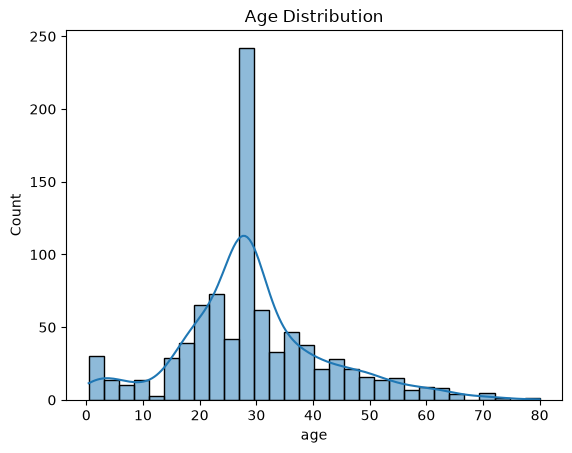

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

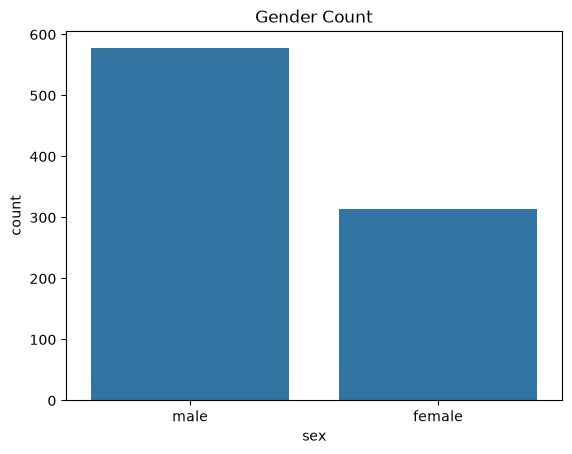

In [33]:
sns.countplot(data=df,x='sex')
plt.title('Gender Count')
plt.show()

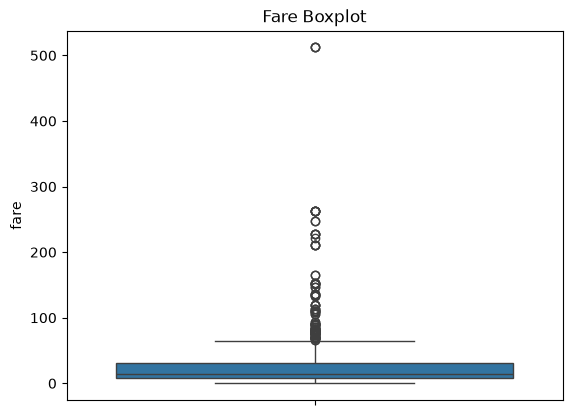

In [34]:
sns.boxplot(y=df['fare'])

plt.title('Fare Boxplot')
plt.show()

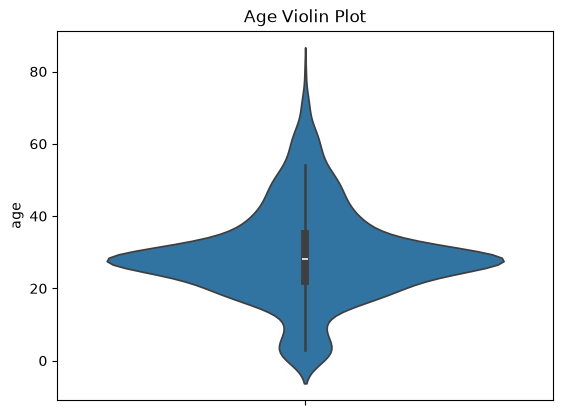

In [35]:
sns.violinplot( y='age', data=df)
plt.title('Age Violin Plot')
plt.show()

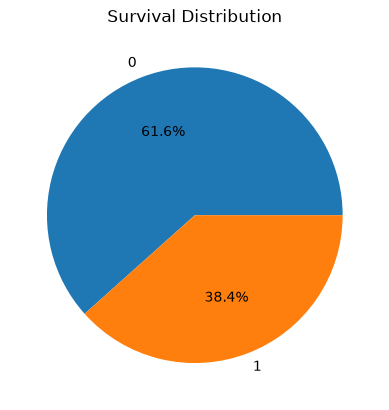

In [36]:
df['survived'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Survival Distribution')
plt.show()

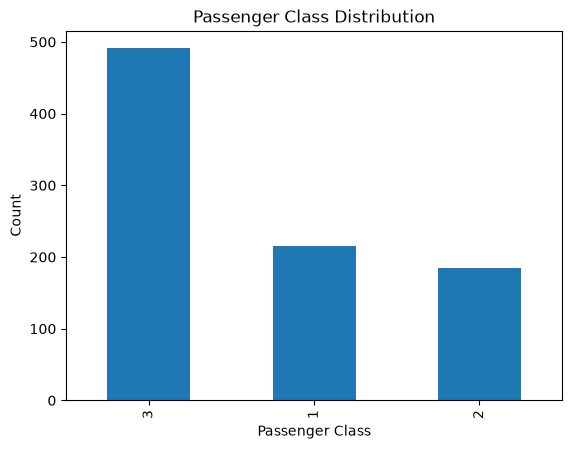

In [37]:
df['pclass'].value_counts().plot(kind='bar')
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

## Task-9 : Bivariate Analysis

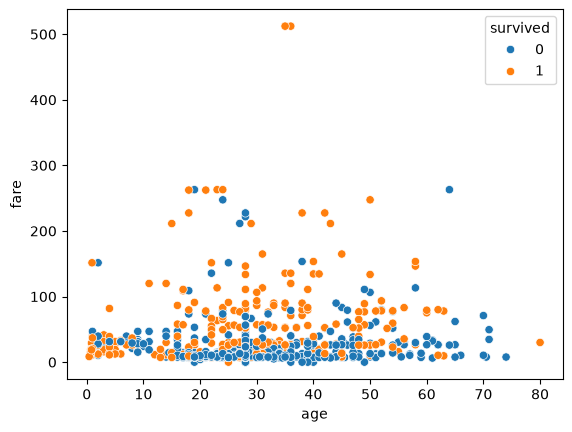

In [38]:
sns.scatterplot(data=df, x='age', y='fare', hue='survived')
plt.show()

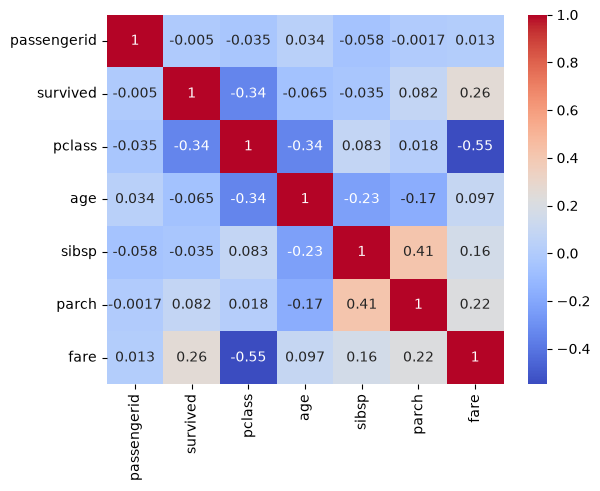

In [39]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

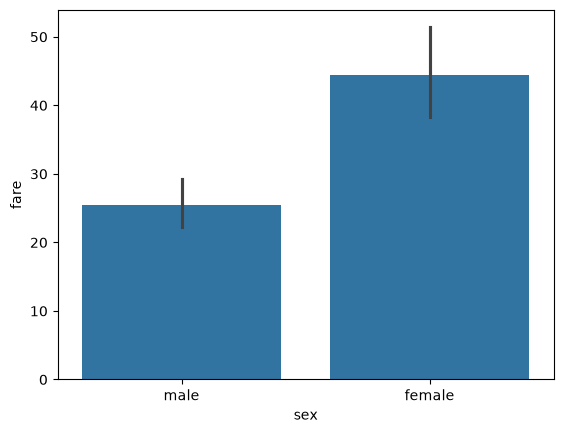

In [40]:
sns.barplot(x='sex', y='fare', data=df)
plt.show()

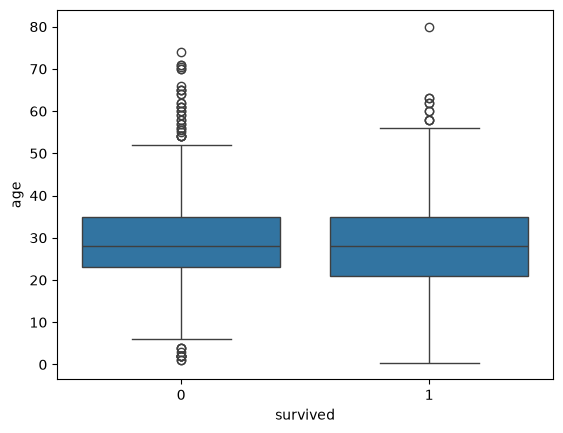

In [41]:
sns.boxplot(data=df, x='survived', y='age')
plt.show()

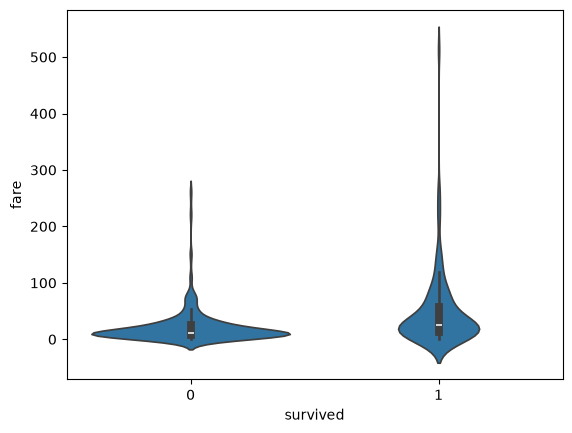

In [42]:
sns.violinplot(x='survived', y='fare', data=df)
plt.show()

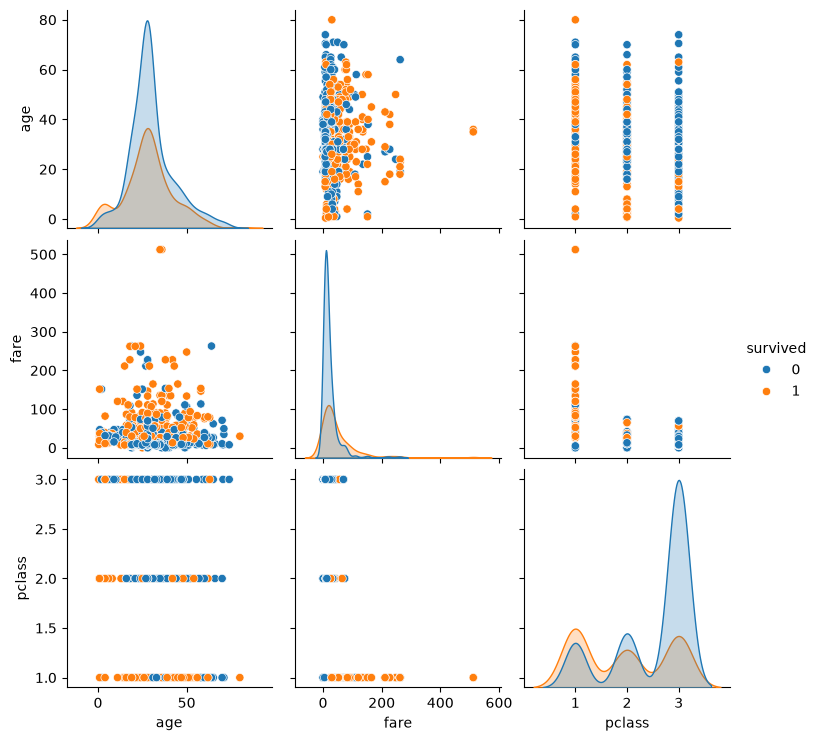

In [43]:
sns.pairplot(df[['age','fare','survived','pclass']], hue='survived')
plt.show()

## Task - 10

## Insights & Observations

1. Most passengers were between 20 and 40 years old.

2. Female passengers had a higher survival rate than male passengers.

3. First-class passengers generally paid higher fares than second- and third-class passengers.

4. The Fare column contains several high-value outliers, as shown in the box plot.

5. The dataset had missing values in the Age, Cabin, and Embarked columns. Missing values were handled by filling numerical columns with the median, categorical columns with the mode, and dropping the Cabin column due to a large number of missing values.

6. The correlation heatmap indicates that Fare and Passenger Class have a moderate relationship, while most other numerical features have weak correlations.

7. Passenger class and gender appear to have a noticeable impact on survival, suggesting they are important features for predictive modeling.